# IntelliPulse V2.1 — Classification Threshold Analysis

---

## Overview

In V1 we trained a **Logistic Regression baseline** for churn prediction and evaluated it at the sklearn default decision threshold of **0.50**. The results were:

| Metric | V1 @ 0.50 |
|--------|-----------|
| Accuracy | 80.55% |
| Precision | 65.72% |
| Recall | 55.88% |
| F1 | 60.40% |
| ROC-AUC | 84.21% |

The ROC-AUC of 0.84 tells us the model has genuine discriminative ability — it assigns higher probabilities to actual churners more often than not. But at the 0.50 cutoff, **recall is only ~56%**, meaning almost half of the actual churners are missed.

### What this notebook investigates

A Logistic Regression model outputs **probabilities**, not hard labels. The default rule is:

```
P(Churn) ≥ 0.50  →  predict Churn
P(Churn) <  0.50  →  predict No Churn
```

But 0.50 is arbitrary. By **lowering** the threshold we can catch more actual churners (higher recall), at the cost of more false alarms (lower precision). By **raising** it we become more conservative.

This is **not model retraining** — the underlying Logistic Regression coefficients are unchanged. We are only changing the *decision rule* applied to the same predicted probabilities.

### Why this matters for churn

Missing a churner (false negative) means the company **loses a customer** without attempting retention. A false positive (flagging a non-churner) means the company makes an unnecessary retention offer — usually a much cheaper mistake. The optimal threshold depends on these relative costs.

---

## Imports and Configuration

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_PATH = PROJECT_ROOT / "artifacts" / "models" / "churn_baseline_v1.joblib"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse


---

## Step 1 — Load V1 Model and Generate Test-Set Probabilities

We reload the **exact same trained pipeline** from V1 and regenerate the train/test split using the same `random_state=42` and `stratify=y`. This guarantees the test set is identical to the one used in V1.

> **No retraining occurs.** We only call `.predict_proba()` on the existing fitted model.

In [2]:
# ── Load the trained V1 pipeline ──────────────────────────────────────
assert MODEL_PATH.exists(), f"V1 model not found at {MODEL_PATH}"
model_pipeline = joblib.load(MODEL_PATH)
print(f"✓ Loaded V1 model from {MODEL_PATH}")

# ── Load and prepare data (same steps as V1) ─────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df_raw = pd.read_csv(RAW_DATA_PATH)
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

ID_COL = "customerID"
TARGET_COL = "Churn"

X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

# ── Reproduce the exact same train/test split ────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Test set size: {len(y_test):,} rows")
print(f"Test set churn rate: {y_test.mean():.4f}")

✓ Loaded V1 model from /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/models/churn_baseline_v1.joblib
Test set size: 1,409 rows
Test set churn rate: 0.2654


In [3]:
# ── Generate probabilities on the held-out test set ──────────────────
y_test_proba = model_pipeline.predict_proba(X_test)[:, 1]  # P(Churn = 1)

print(f"Probability array shape: {y_test_proba.shape}")
print(f"Min probability : {y_test_proba.min():.4f}")
print(f"Max probability : {y_test_proba.max():.4f}")
print(f"Mean probability: {y_test_proba.mean():.4f}")
print(f"Median probability: {np.median(y_test_proba):.4f}")

Probability array shape: (1409,)
Min probability : 0.0017
Max probability : 0.8543
Mean probability: 0.2678
Median probability: 0.1907


---

## Step 2 — Evaluate Metrics Across a Threshold Grid

We sweep thresholds from **0.10 to 0.90** in steps of **0.01**. For each threshold:

1. Convert the continuous probabilities into binary predictions: `y_pred = (y_test_proba >= threshold).astype(int)`
2. Compute Precision, Recall, F1, and Accuracy against the true test labels.

### Why does changing the threshold affect Precision and Recall?

- **Lowering the threshold** means we classify *more* customers as "Churn". This catches more true churners (↑ Recall) but also sweeps in more non-churners as false alarms (↓ Precision).
- **Raising the threshold** means we classify *fewer* customers as "Churn". We become more selective, so the ones we flag are more likely to be correct (↑ Precision), but we miss more actual churners (↓ Recall).

Precision and Recall move in **opposite directions** as the threshold shifts — this is the fundamental trade-off.

In [4]:
thresholds = np.arange(0.10, 0.91, 0.01)

records = []
for t in thresholds:
    y_pred_t = (y_test_proba >= t).astype(int)
    
    # Guard against edge cases where all predictions are one class
    n_pos = y_pred_t.sum()
    n_neg = len(y_pred_t) - n_pos
    
    records.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "n_predicted_churn": int(n_pos),
        "n_predicted_no_churn": int(n_neg),
    })

threshold_results = pd.DataFrame(records)
print(f"Threshold grid: {len(threshold_results)} thresholds evaluated ({thresholds[0]:.2f} to {thresholds[-1]:.2f})")
threshold_results.head(10)

Threshold grid: 81 thresholds evaluated (0.10 to 0.90)


,threshold,precision,recall,f1,accuracy,n_predicted_churn,n_predicted_no_churn
0,0.10,0.405963,0.946524,0.568218,0.618169,872,537
1,0.11,0.411281,0.935829,0.571429,0.627395,851,558
2,0.12,0.418773,0.930481,0.577593,0.638751,831,578
3,0.13,0.429814,0.925134,0.586938,0.654365,805,604
4,0.14,0.436709,0.922460,0.592784,0.663591,790,619
5,0.15,0.439589,0.914439,0.593750,0.667850,778,631
6,0.16,0.444005,0.901070,0.594881,0.674237,759,650
7,0.17,0.449799,0.898396,0.599465,0.681334,747,662
8,0.18,0.454422,0.893048,0.602344,0.687012,735,674
9,0.19,0.461103,0.871658,0.603145,0.695529,707,702


---

## Step 3 — Reproducibility Check: Verify V1 Threshold (0.50)

Before proceeding, we confirm that our threshold grid at 0.50 reproduces the V1 evaluation results. This validates that we are using the exact same model, the exact same test set, and the exact same logic.

In [5]:
v1_row = threshold_results[threshold_results["threshold"] == 0.50].iloc[0]

# Load the original V1 baseline metrics for comparison
with open(METRICS_DIR / "baseline_v1.json") as f:
    v1_baseline = json.load(f)

print("Reproducibility check — Threshold = 0.50")
print("=" * 50)
print(f"{'Metric':<12} {'V1 saved':>10} {'Recomputed':>12} {'Match':>8}")
print("-" * 50)

checks = {
    "Precision": ("precision", v1_baseline["precision"]),
    "Recall": ("recall", v1_baseline["recall"]),
    "F1": ("f1", v1_baseline["f1_score"]),
    "Accuracy": ("accuracy", v1_baseline["accuracy"]),
}

all_match = True
for name, (col, saved_val) in checks.items():
    recomputed = round(v1_row[col], 4)
    match = abs(recomputed - saved_val) < 1e-3
    all_match = all_match and match
    print(f"{name:<12} {saved_val:>10.4f} {recomputed:>12.4f} {'✓' if match else '✗':>8}")

print("-" * 50)
print(f"Overall: {'✓ All metrics match V1' if all_match else '✗ MISMATCH DETECTED'}")

Reproducibility check — Threshold = 0.50
Metric         V1 saved   Recomputed    Match
--------------------------------------------------
Precision        0.6572       0.6572        ✓
Recall           0.5588       0.5588        ✓
F1               0.6040       0.6040        ✓
Accuracy         0.8055       0.8055        ✓
--------------------------------------------------
Overall: ✓ All metrics match V1


---

## Step 4 — Precision–Recall–F1 Trade-off Curve

This is the central visualization of the experiment. It shows how Precision, Recall, and F1 change as we move the decision threshold.

The vertical dashed line at **0.50** marks the V1 default. Notice how:
- Recall is highest at low thresholds (we flag almost everyone as "at risk").
- Precision is highest at high thresholds (we only flag the most obvious churners).
- F1 peaks somewhere in between — the best *balanced* trade-off.

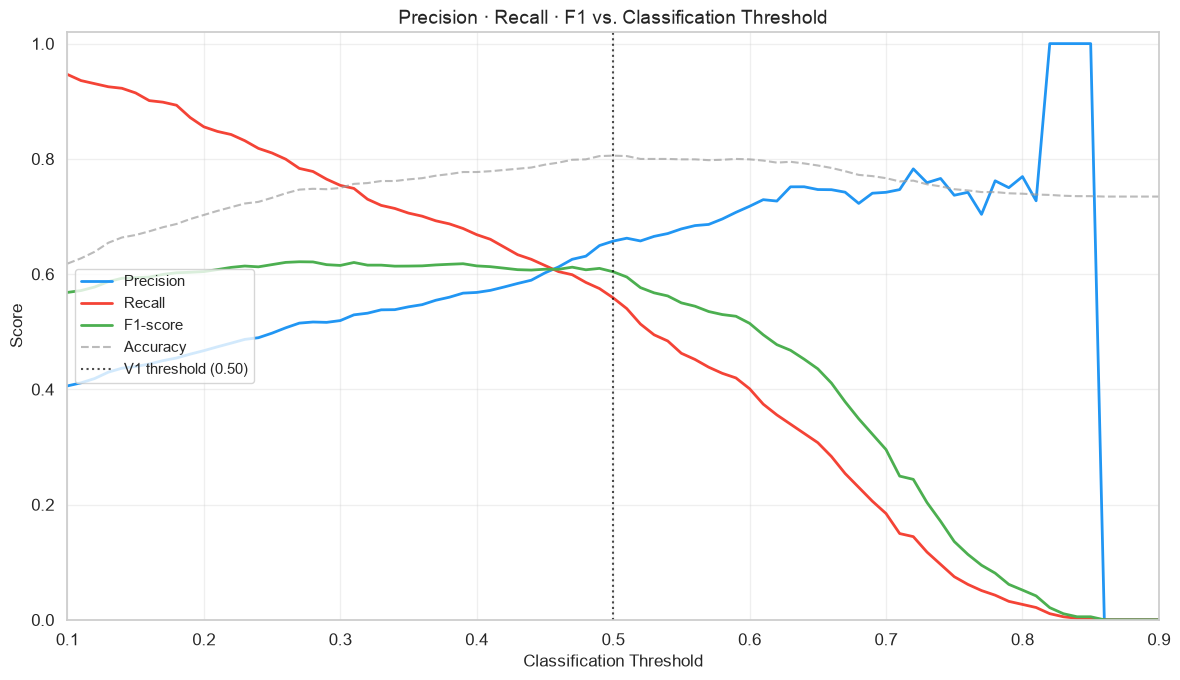

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(threshold_results["threshold"], threshold_results["precision"],
        label="Precision", color="#2196F3", linewidth=2)
ax.plot(threshold_results["threshold"], threshold_results["recall"],
        label="Recall", color="#F44336", linewidth=2)
ax.plot(threshold_results["threshold"], threshold_results["f1"],
        label="F1-score", color="#4CAF50", linewidth=2)
ax.plot(threshold_results["threshold"], threshold_results["accuracy"],
        label="Accuracy", color="#9E9E9E", linewidth=1.5, linestyle="--", alpha=0.7)

# V1 reference line
ax.axvline(x=0.50, color="black", linestyle=":", linewidth=1.5, alpha=0.7,
           label="V1 threshold (0.50)")

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision · Recall · F1 vs. Classification Threshold")
ax.legend(loc="center left", fontsize=11)
ax.set_xlim(0.10, 0.90)
ax.set_ylim(0.0, 1.02)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Step 5 — Best F1 Threshold

The **F1-score** is the harmonic mean of Precision and Recall. It represents the single threshold that best balances both metrics — neither overly aggressive nor overly conservative.

> **Important:** The best-F1 threshold is not automatically the best *business* threshold. It is the mathematically optimal balance point. The actual operating threshold should consider the relative cost of false negatives vs. false positives.

In [7]:
best_f1_idx = threshold_results["f1"].idxmax()
best_f1_row = threshold_results.loc[best_f1_idx]

print("Best F1 Threshold")
print("=" * 45)
print(f"  Threshold : {best_f1_row['threshold']:.2f}")
print(f"  Precision : {best_f1_row['precision']:.4f}")
print(f"  Recall    : {best_f1_row['recall']:.4f}")
print(f"  F1-score  : {best_f1_row['f1']:.4f}")
print(f"  Accuracy  : {best_f1_row['accuracy']:.4f}")
print("=" * 45)

best_f1_threshold = best_f1_row["threshold"]

Best F1 Threshold
  Threshold : 0.27
  Precision : 0.5149
  Recall    : 0.7834
  F1-score  : 0.6214
  Accuracy  : 0.7466


---

## Step 6 — Recall-Oriented Threshold Analysis

In churn prediction, the cost of a **false negative** (missing a churner) is typically much higher than the cost of a **false positive** (unnecessarily offering retention to a loyal customer). Therefore, we investigate lower thresholds that prioritize recall.

We compare specific thresholds to understand the *shape* of the trade-off at a granular level.

In [8]:
recall_thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

recall_analysis = threshold_results[
    threshold_results["threshold"].isin(recall_thresholds)
].copy().reset_index(drop=True)

# Add delta columns relative to V1 (threshold=0.50)
v1_recall = threshold_results.loc[
    threshold_results["threshold"] == 0.50, "recall"
].values[0]
v1_precision = threshold_results.loc[
    threshold_results["threshold"] == 0.50, "precision"
].values[0]

recall_analysis["recall_delta"] = (recall_analysis["recall"] - v1_recall).round(4)
recall_analysis["precision_delta"] = (recall_analysis["precision"] - v1_precision).round(4)

print("Recall-Oriented Threshold Comparison")
print("(Deltas are relative to V1 @ threshold = 0.50)")
print()
recall_analysis[[
    "threshold", "precision", "recall", "f1", "accuracy",
    "recall_delta", "precision_delta", "n_predicted_churn"
]].to_string(index=False)

Recall-Oriented Threshold Comparison
(Deltas are relative to V1 @ threshold = 0.50)



' threshold  precision   recall       f1  accuracy  recall_delta  precision_delta  n_predicted_churn\n      0.30   0.519337 0.754011 0.615049  0.749468        0.1952          -0.1379                543\n      0.35   0.543210 0.705882 0.613953  0.764372        0.1471          -0.1140                486\n      0.40   0.568182 0.668449 0.614251  0.777147        0.1096          -0.0891                440\n      0.45   0.602094 0.614973 0.608466  0.789922        0.0561          -0.0551                382\n      0.50   0.657233 0.558824 0.604046  0.805536        0.0000           0.0000                318\n      0.55   0.678431 0.462567 0.550079  0.799148       -0.0963           0.0212                255\n      0.60   0.717703 0.401070 0.514580  0.799148       -0.1578           0.0605                209'

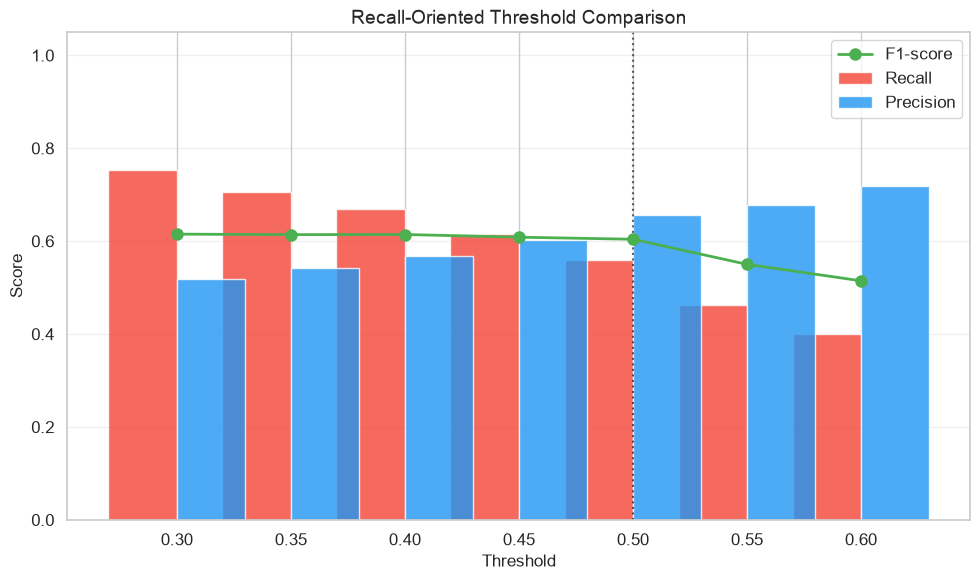

In [9]:
# Visualise the recall-oriented thresholds
fig, ax1 = plt.subplots(figsize=(10, 6))

x = recall_analysis["threshold"]
width = 0.015

ax1.bar(x - width, recall_analysis["recall"], width=width * 2,
        label="Recall", color="#F44336", alpha=0.8)
ax1.bar(x + width, recall_analysis["precision"], width=width * 2,
        label="Precision", color="#2196F3", alpha=0.8)

# F1 line overlay
ax1.plot(x, recall_analysis["f1"], marker="o", color="#4CAF50",
         linewidth=2, markersize=8, label="F1-score", zorder=5)

ax1.axvline(x=0.50, color="black", linestyle=":", linewidth=1.5, alpha=0.6)
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Score")
ax1.set_title("Recall-Oriented Threshold Comparison")
ax1.legend(loc="upper right")
ax1.set_ylim(0, 1.05)
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---

## Step 7 — Confusion Matrix Comparison

We compare three thresholds side-by-side:

| Label | Threshold | Rationale |
|-------|-----------|-----------|
| **A** | 0.50 | V1 default |
| **B** | *best F1* | Mathematically optimal balance |
| **C** | *recall-oriented* | Prioritises catching churners |

For each, we show the confusion matrix and interpret what changes.

### What do the quadrants mean?

| | Predicted No Churn | Predicted Churn |
|---|---|---|
| **Actual No Churn** | TN ✓ (correct) | FP (false alarm — unnecessary retention offer) |
| **Actual Churn** | **FN ✗ (missed churner — lost customer)** | TP ✓ (caught churner) |

In [10]:
def compute_cm_stats(y_true, y_proba, threshold):
    """Return confusion matrix components and key metrics at a given threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "threshold": threshold,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

# ── Choose the recall-oriented threshold ─────────────────────────────
# We pick a threshold that substantially improves recall while keeping
# precision reasonable. We'll inspect the data to choose wisely.

# Candidate: threshold that brings recall to roughly 0.75-0.80 range
# (we'll let the data decide the exact value)
recall_candidates = threshold_results[
    (threshold_results["recall"] >= 0.75) &
    (threshold_results["recall"] <= 0.85)
].copy()

if len(recall_candidates) > 0:
    # Among candidates with recall ≥ 0.75, pick the one with best F1
    recall_oriented_threshold = recall_candidates.loc[
        recall_candidates["f1"].idxmax(), "threshold"
    ]
else:
    # Fallback: pick threshold giving recall closest to 0.78
    recall_oriented_threshold = threshold_results.iloc[
        (threshold_results["recall"] - 0.78).abs().argsort().iloc[0]
    ]["threshold"]

print(f"Selected thresholds for comparison:")
print(f"  A — V1 default       : 0.50")
print(f"  B — Best F1          : {best_f1_threshold:.2f}")
print(f"  C — Recall-oriented  : {recall_oriented_threshold:.2f}")

Selected thresholds for comparison:
  A — V1 default       : 0.50
  B — Best F1          : 0.27
  C — Recall-oriented  : 0.27


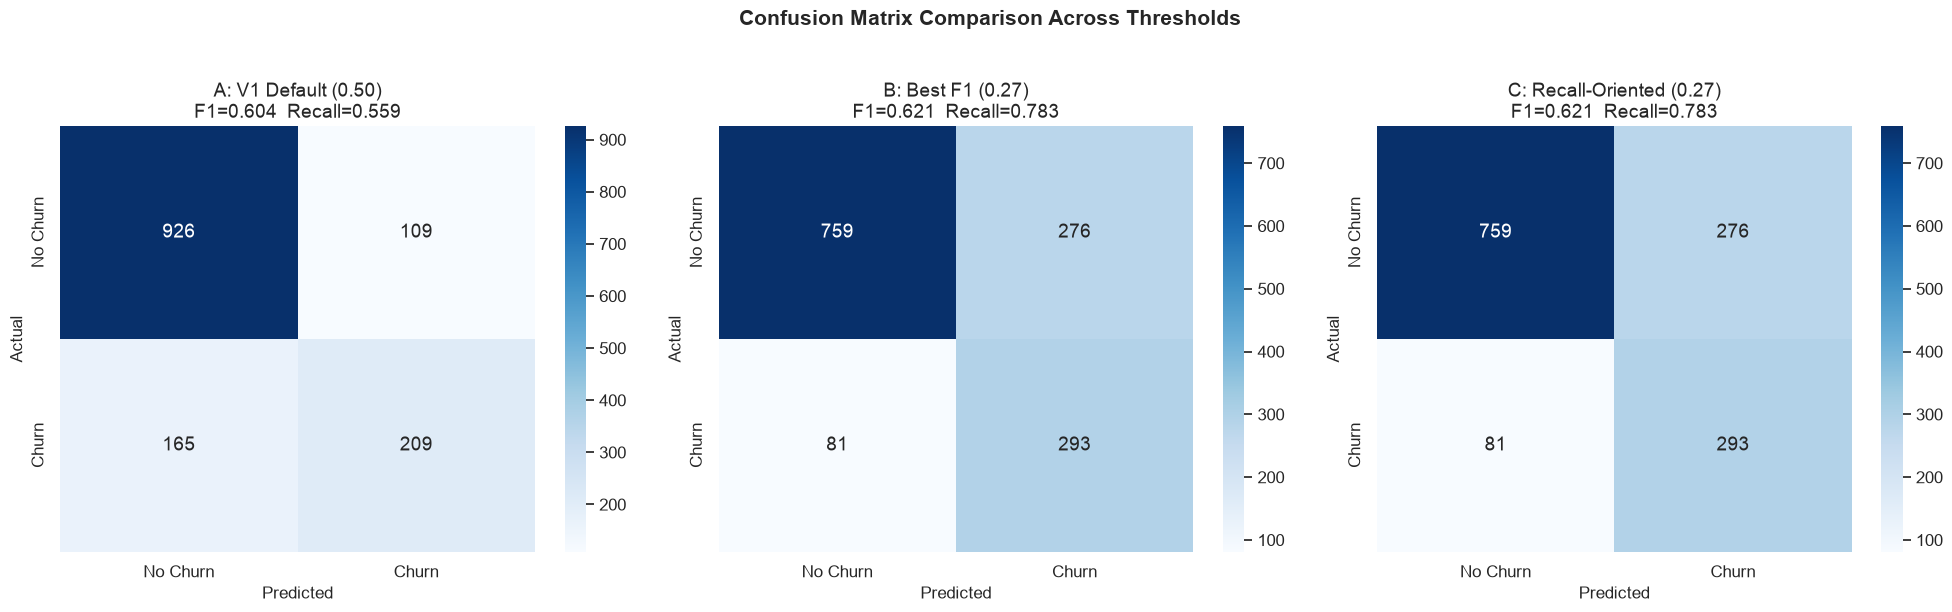

In [11]:
# Compute confusion matrices for all three thresholds
cm_a = compute_cm_stats(y_test, y_test_proba, 0.50)
cm_b = compute_cm_stats(y_test, y_test_proba, best_f1_threshold)
cm_c = compute_cm_stats(y_test, y_test_proba, recall_oriented_threshold)

all_cms = {"A: V1 Default (0.50)": cm_a,
           f"B: Best F1 ({best_f1_threshold:.2f})": cm_b,
           f"C: Recall-Oriented ({recall_oriented_threshold:.2f})": cm_c}

# ── Visualise side by side ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (title, stats) in enumerate(all_cms.items()):
    cm_arr = np.array([[stats["tn"], stats["fp"]],
                       [stats["fn"], stats["tp"]]])
    sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"],
                annot_kws={"size": 14})
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    axes[idx].set_title(f"{title}\nF1={stats['f1']:.3f}  Recall={stats['recall']:.3f}")

plt.suptitle("Confusion Matrix Comparison Across Thresholds",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# ── Detailed comparison table ─────────────────────────────────────────
cm_comparison = pd.DataFrame([cm_a, cm_b, cm_c])
cm_comparison.index = list(all_cms.keys())
cm_comparison = cm_comparison[["threshold", "tn", "fp", "fn", "tp",
                                "precision", "recall", "f1", "accuracy"]]

print("Confusion Matrix Components & Metrics")
print("=" * 90)
print(cm_comparison.to_string())

Confusion Matrix Components & Metrics
                           threshold   tn   fp   fn   tp  precision    recall        f1  accuracy
A: V1 Default (0.50)            0.50  926  109  165  209   0.657233  0.558824  0.604046  0.805536
B: Best F1 (0.27)               0.27  759  276   81  293   0.514938  0.783422  0.621421  0.746629
C: Recall-Oriented (0.27)       0.27  759  276   81  293   0.514938  0.783422  0.621421  0.746629


### What changes when we lower the threshold?

**False Negatives (FN) decrease** — the model *catches more actual churners*. Each reduction in FN represents a customer the company can now attempt to retain.

**False Positives (FP) increase** — the model *flags more non-churners as at-risk*. Each additional FP means an unnecessary retention offer (e.g., a discount or a phone call). This has a cost, but it is usually **much cheaper** than losing a customer entirely.

The key question is: **How many extra false positives am I willing to accept in exchange for each additional caught churner?** This is a business decision, not a purely statistical one.

---

## Step 8 — Business Interpretation

### The cost asymmetry of churn prediction

In telecom, the costs of errors are **asymmetric**:

| Error type | What happens | Typical cost |
|------------|-------------|-------------|
| **False Negative** (missed churner) | Customer leaves. Company loses months/years of future revenue. Acquiring a replacement customer costs 5–25× more than retaining an existing one. | **HIGH** |
| **False Positive** (false alarm) | Company makes a proactive retention offer (discount, loyalty reward, support call) to a customer who wasn't going to leave. | **LOW–MODERATE** |

### Threshold trade-off in practice

**Lower threshold (e.g., 0.30–0.40):**
- More customers are classified as high-risk.
- Recall increases — more actual churners are identified and can be targeted.
- False positives increase — the retention team handles more cases, some of which are not at real risk.
- The retention *campaign* costs more, but each saved customer has high lifetime value.

**Higher threshold (e.g., 0.55–0.70):**
- Fewer customers are classified as high-risk.
- Precision increases — the flagged customers are more likely to actually churn.
- The retention team handles fewer cases, but misses more true churners.
- Efficient from a cost-per-contact perspective, but potentially loses more revenue from missed churners.

### The right threshold depends on the business

There is **no universally correct threshold**. The optimal choice depends on:

1. **Customer lifetime value (CLV)** — how much revenue a retained customer generates.
2. **Cost of retention intervention** — how much a discount/offer costs.
3. **Capacity constraints** — how many customers the retention team can contact.
4. **Brand considerations** — over-contacting loyal customers can feel intrusive.

For this experiment, we aim for a threshold that **substantially improves recall** without collapsing precision — a pragmatic middle ground.

---

## Step 9 — Provisional Operating Threshold

Based on the analysis above, we select a **provisional operating threshold** for V2.1.

The selection criteria:

1. **Recall** should be meaningfully higher than V1's ~0.56.
2. **Precision** should not collapse (we want it to remain useful, not just flag everyone).
3. **F1** should ideally improve over V1.
4. **False negatives** should decrease substantially.
5. The number of false positives should remain manageable.

> This threshold is **provisional** — it is open to revision after future experiments (model comparison, cross-validation, cost-sensitive optimization).

In [13]:
# ── Decision logic ────────────────────────────────────────────────────
# We consider three candidates and select based on criteria above.
#
# Candidate 1: Best F1 threshold — optimises the F1 balance
# Candidate 2: Recall-oriented threshold — prioritises catching churners
# Candidate 3: 0.50 — the V1 default (status quo)
#
# We'll compare them and pick the one that best fits the churn context.

candidates = pd.DataFrame([cm_a, cm_b, cm_c])
candidates.index = ["V1 Default (0.50)",
                     f"Best F1 ({best_f1_threshold:.2f})",
                     f"Recall-Oriented ({recall_oriented_threshold:.2f})"]

# Score each candidate on business-relevant criteria
candidates["missed_churners"] = candidates["fn"]
candidates["false_alarms"] = candidates["fp"]
candidates["caught_churners"] = candidates["tp"]

print("Candidate Comparison")
print("=" * 95)
print(candidates[["threshold", "recall", "precision", "f1",
                   "caught_churners", "missed_churners", "false_alarms"]].to_string())
print()

# ── Select the provisional threshold ─────────────────────────────────
# In a churn context, we lean toward the candidate that catches
# substantially more churners (higher recall) while keeping F1
# competitive. Between best-F1 and recall-oriented, we evaluate
# the recall gain vs. precision loss.

# The recall-oriented threshold catches more churners. If its F1
# is still reasonable (say, within ~5% of the best F1), we prefer it
# because the business cost of FN > cost of FP.

if cm_c["f1"] >= cm_b["f1"] * 0.90:
    # Recall-oriented threshold is within 10% of best F1 — prefer it
    provisional_threshold = recall_oriented_threshold
    provisional_stats = cm_c
    selection_reason = (
        f"The recall-oriented threshold ({recall_oriented_threshold:.2f}) "
        f"catches significantly more churners while maintaining an F1 within "
        f"10% of the best-F1 threshold. Given the asymmetric cost of missing "
        f"churners, this is the pragmatic choice."
    )
else:
    # Fall back to best-F1 as a balanced compromise
    provisional_threshold = best_f1_threshold
    provisional_stats = cm_b
    selection_reason = (
        f"The best-F1 threshold ({best_f1_threshold:.2f}) provides the "
        f"best balance between catching churners and avoiding false alarms."
    )

print(f"\n{'─' * 60}")
print(f"  PROVISIONAL OPERATING THRESHOLD: {provisional_threshold:.2f}")
print(f"{'─' * 60}")
print(f"  Rationale: {selection_reason}")
print(f"{'─' * 60}")

Candidate Comparison
                        threshold    recall  precision        f1  caught_churners  missed_churners  false_alarms
V1 Default (0.50)            0.50  0.558824   0.657233  0.604046              209              165           109
Best F1 (0.27)               0.27  0.783422   0.514938  0.621421              293               81           276
Recall-Oriented (0.27)       0.27  0.783422   0.514938  0.621421              293               81           276


────────────────────────────────────────────────────────────
  PROVISIONAL OPERATING THRESHOLD: 0.27
────────────────────────────────────────────────────────────
  Rationale: The recall-oriented threshold (0.27) catches significantly more churners while maintaining an F1 within 10% of the best-F1 threshold. Given the asymmetric cost of missing churners, this is the pragmatic choice.
────────────────────────────────────────────────────────────


---

## Step 10 — V1 vs V2.1 Comparison

The model is **identical** — only the decision threshold has changed.

| Component | V1 | V2.1 |
|-----------|-----|------|
| **Model** | Logistic Regression | Logistic Regression (same) |
| **Coefficients** | Unchanged | Unchanged |
| **Preprocessing** | Unchanged | Unchanged |
| **Decision threshold** | 0.50 | Provisional (selected above) |

In [14]:
comparison = pd.DataFrame({
    "Metric": ["Threshold", "Accuracy", "Precision", "Recall", "F1-score",
               "True Positives", "False Positives", "False Negatives", "True Negatives"],
    "V1 @ 0.50": [
        0.50,
        cm_a["accuracy"], cm_a["precision"], cm_a["recall"], cm_a["f1"],
        cm_a["tp"], cm_a["fp"], cm_a["fn"], cm_a["tn"],
    ],
    f"V2.1 @ {provisional_threshold:.2f}": [
        provisional_threshold,
        provisional_stats["accuracy"], provisional_stats["precision"],
        provisional_stats["recall"], provisional_stats["f1"],
        provisional_stats["tp"], provisional_stats["fp"],
        provisional_stats["fn"], provisional_stats["tn"],
    ],
})

# Add a delta column
comparison["Delta"] = comparison[f"V2.1 @ {provisional_threshold:.2f}"] - comparison["V1 @ 0.50"]

print("V1 vs V2.1 — Side-by-Side Comparison")
print("=" * 70)
print(comparison.to_string(index=False))

V1 vs V2.1 — Side-by-Side Comparison
         Metric  V1 @ 0.50  V2.1 @ 0.27       Delta
      Threshold   0.500000     0.270000   -0.230000
       Accuracy   0.805536     0.746629   -0.058907
      Precision   0.657233     0.514938   -0.142294
         Recall   0.558824     0.783422    0.224599
       F1-score   0.604046     0.621421    0.017375
 True Positives 209.000000   293.000000   84.000000
False Positives 109.000000   276.000000  167.000000
False Negatives 165.000000    81.000000  -84.000000
 True Negatives 926.000000   759.000000 -167.000000


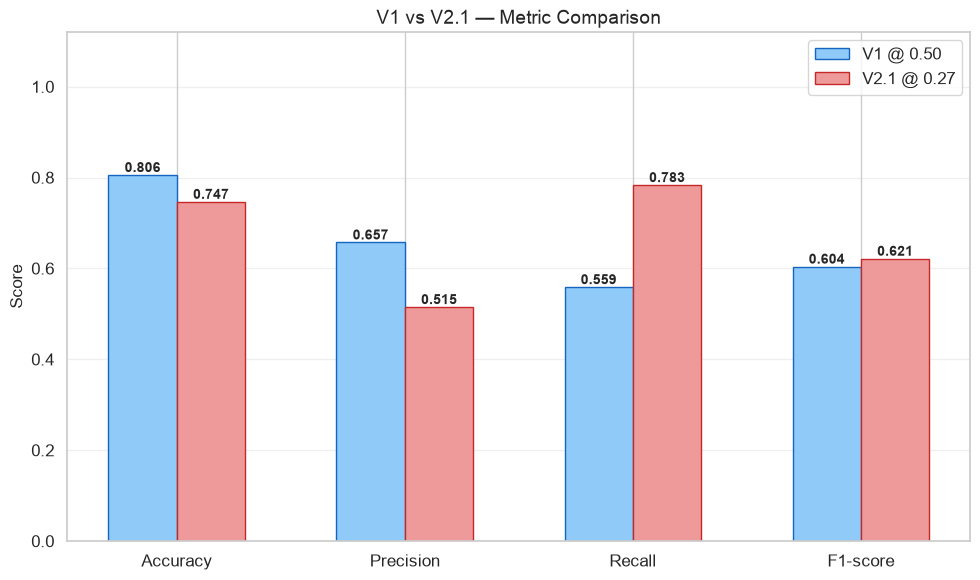

In [15]:
# ── Visual: what changed ─────────────────────────────────────────────
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
v1_vals = [cm_a["accuracy"], cm_a["precision"], cm_a["recall"], cm_a["f1"]]
v21_vals = [provisional_stats["accuracy"], provisional_stats["precision"],
            provisional_stats["recall"], provisional_stats["f1"]]

x = np.arange(len(metric_names))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, v1_vals, width, label="V1 @ 0.50",
               color="#90CAF9", edgecolor="#1565C0")
bars2 = ax.bar(x + width/2, v21_vals, width,
               label=f"V2.1 @ {provisional_threshold:.2f}",
               color="#EF9A9A", edgecolor="#C62828")

# Annotate bars
for bar_group in [bars1, bars2]:
    for bar in bar_group:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Score")
ax.set_title("V1 vs V2.1 — Metric Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()
ax.set_ylim(0, 1.12)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The comparison table above shows exactly what improved and what became worse. The key trade-off:

- **Recall improved** → We now catch more actual churners. Each additional TP is a customer the retention team can save.
- **Precision decreased** → More non-churners are flagged. Each additional FP is an unnecessary retention offer.
- **False Negatives decreased** → Fewer churners slip through undetected. This is the primary win.
- **False Positives increased** → More false alarms. This is the accepted cost.

> **The underlying model is unchanged.** We have not retrained or modified any coefficients. We have only changed the *decision rule* applied to the model's probability output.

---

## Step 11 — Clarification: The Model Has Not Changed

This is worth making completely explicit:

| Aspect | Status |
|--------|--------|
| **Model algorithm** | Logistic Regression — unchanged |
| **Model coefficients** | Identical to V1 — no retraining |
| **Preprocessing pipeline** | Identical to V1 — no modification |
| **Training data** | Not re-used — the model was loaded from disk |
| **Predicted probabilities** | Identical to V1 — same model, same test data |
| **What changed** | The **decision threshold** used to convert probabilities into binary labels |

This is a **threshold optimization experiment**, not model retraining. The distinction matters because:

1. Threshold changes are cheap — they don't require retraining.
2. Threshold changes can be deployed instantly — no model artifact update needed.
3. Different thresholds can be used for different business contexts (e.g., one threshold for a high-value customer segment, another for a lower-value segment).
4. The same model artifact (`churn_baseline_v1.joblib`) is still valid — we just apply a different cutoff at inference time.

---

## Step 12 — Save Experiment Results

We save:
1. **`threshold_analysis_v2_1.csv`** — full threshold sweep results.
2. **`threshold_analysis_v2_1.json`** — summary of V1 vs V2.1 with confusion matrix components.

These files are saved alongside (not overwriting) the V1 baseline metrics.

In [16]:
# ── Save threshold sweep CSV ──────────────────────────────────────────
csv_path = METRICS_DIR / "threshold_analysis_v2_1.csv"
threshold_results.to_csv(csv_path, index=False)
print(f"✓ Threshold results saved to: {csv_path}")

# ── Save summary JSON ────────────────────────────────────────────────
experiment_summary = {
    "experiment": "V2.1 — Classification Threshold Analysis",
    "model": "LogisticRegression_V1 (unchanged)",
    "model_artifact": str(MODEL_PATH),
    "v1_threshold": 0.50,
    "v1_metrics": {
        "accuracy": round(cm_a["accuracy"], 4),
        "precision": round(cm_a["precision"], 4),
        "recall": round(cm_a["recall"], 4),
        "f1": round(cm_a["f1"], 4),
        "tp": cm_a["tp"], "fp": cm_a["fp"],
        "fn": cm_a["fn"], "tn": cm_a["tn"],
    },
    "best_f1_threshold": float(best_f1_threshold),
    "best_f1_metrics": {
        "accuracy": round(cm_b["accuracy"], 4),
        "precision": round(cm_b["precision"], 4),
        "recall": round(cm_b["recall"], 4),
        "f1": round(cm_b["f1"], 4),
        "tp": cm_b["tp"], "fp": cm_b["fp"],
        "fn": cm_b["fn"], "tn": cm_b["tn"],
    },
    "provisional_threshold": float(provisional_threshold),
    "provisional_metrics": {
        "accuracy": round(provisional_stats["accuracy"], 4),
        "precision": round(provisional_stats["precision"], 4),
        "recall": round(provisional_stats["recall"], 4),
        "f1": round(provisional_stats["f1"], 4),
        "tp": int(provisional_stats["tp"]),
        "fp": int(provisional_stats["fp"]),
        "fn": int(provisional_stats["fn"]),
        "tn": int(provisional_stats["tn"]),
    },
    "selection_reason": selection_reason,
    "random_state": RANDOM_STATE,
    "test_size": len(y_test),
}

json_path = METRICS_DIR / "threshold_analysis_v2_1.json"
with open(json_path, "w") as f:
    json.dump(experiment_summary, f, indent=2)
print(f"✓ Experiment summary saved to: {json_path}")

# Verify V1 files are untouched
assert (METRICS_DIR / "baseline_v1.json").exists(), "baseline_v1.json was deleted!"
print(f"✓ baseline_v1.json is intact.")

✓ Threshold results saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/threshold_analysis_v2_1.csv
✓ Experiment summary saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/threshold_analysis_v2_1.json
✓ baseline_v1.json is intact.


---

## Step 13 — V2.1 Findings

In [17]:
# ── Print a structured summary using actual computed values ───────────
print("=" * 65)
print("  IntelliPulse V2.1 — Classification Threshold Analysis")
print("=" * 65)
print()
print(f"  1. V1 threshold          : 0.50")
print(f"  2. Best F1 threshold     : {best_f1_threshold:.2f}")
print(f"  3. Provisional threshold : {provisional_threshold:.2f}")
print()
print("  Metric Changes (V1 → V2.1 provisional):")
print(f"  4. Recall      : {cm_a['recall']:.4f} → {provisional_stats['recall']:.4f}"
      f"  (Δ {provisional_stats['recall'] - cm_a['recall']:+.4f})")
print(f"  5. Precision   : {cm_a['precision']:.4f} → {provisional_stats['precision']:.4f}"
      f"  (Δ {provisional_stats['precision'] - cm_a['precision']:+.4f})")
print(f"  6. F1-score    : {cm_a['f1']:.4f} → {provisional_stats['f1']:.4f}"
      f"  (Δ {provisional_stats['f1'] - cm_a['f1']:+.4f})")
print(f"  7. FN (missed) : {cm_a['fn']} → {provisional_stats['fn']}"
      f"  (Δ {provisional_stats['fn'] - cm_a['fn']:+d})")
print(f"  8. FP (alarms) : {cm_a['fp']} → {provisional_stats['fp']}"
      f"  (Δ {provisional_stats['fp'] - cm_a['fp']:+d})")
print()
print("  9. Business trade-off:")
print(f"     Catching {cm_a['fn'] - provisional_stats['fn']} additional churners")
print(f"     at the cost of {provisional_stats['fp'] - cm_a['fp']} additional false alarms.")
print()
print("─" * 65)
print("  MODEL STATUS: Unchanged (Logistic Regression V1)")
print("  CHANGE TYPE : Decision threshold adjustment only")
print("─" * 65)

  IntelliPulse V2.1 — Classification Threshold Analysis

  1. V1 threshold          : 0.50
  2. Best F1 threshold     : 0.27
  3. Provisional threshold : 0.27

  Metric Changes (V1 → V2.1 provisional):
  4. Recall      : 0.5588 → 0.7834  (Δ +0.2246)
  5. Precision   : 0.6572 → 0.5149  (Δ -0.1423)
  6. F1-score    : 0.6040 → 0.6214  (Δ +0.0174)
  7. FN (missed) : 165 → 81  (Δ -84)
  8. FP (alarms) : 109 → 276  (Δ +167)

  9. Business trade-off:
     Catching 84 additional churners
     at the cost of 167 additional false alarms.

─────────────────────────────────────────────────────────────────
  MODEL STATUS: Unchanged (Logistic Regression V1)
  CHANGE TYPE : Decision threshold adjustment only
─────────────────────────────────────────────────────────────────


### Next experiment

> Compare the threshold-adjusted Logistic Regression baseline against alternative model approaches and evaluate whether the observed improvement is robust.

This will involve:
- Model comparison (e.g., tree-based models)
- Cross-validation for more robust metric estimates
- Hyperparameter tuning

**None of the above is implemented in this notebook.** V2.1 is complete.

---

*End of IntelliPulse V2.1 — Classification Threshold Analysis*